### Deep Agents overview



Build agents that can plan, use subagents, and leverage file systems for complex tasks

deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.


### When to use deep agents
Use deep agents when you need agents that can:

- Handle complex, multi-step tasks that require planning and decomposition
- Manage large amounts of context through file system tools
- Delegate work to specialized subagents for context isolation
- Persist memory across conversations and threads

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GOOGLE_API_KEY"]  = os.environ.get("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"]  = os.environ.get("TAVILY_API_KEY")

In [13]:
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient()

def web_search(query:str, max_results:int=5, topic:Literal["sport", "news","finance"]="general", 
include_raw_content:bool=False):
  """Run a web search"""
  
  return tavily_client.search(query=query, max_results=max_results, topic=topic, include_raw_content=include_raw_content)

In [14]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "gemini-2.5-flash",
    model_provider="google_genai"
)

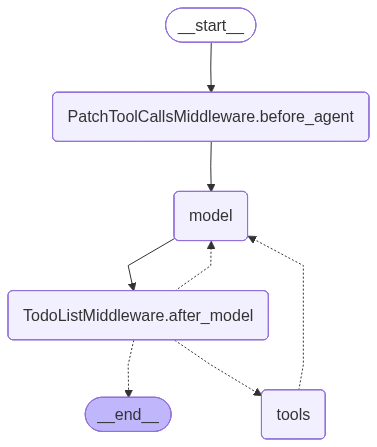

In [15]:
from deepagents import create_deep_agent

agent = create_deep_agent(
  model=model,
  tools=[web_search],
  system_prompt="Act as a deep researcher"
)


agent


In [31]:
result = agent.invoke({"messages": [{"role": "user", "content": "Find Ankush Dharkar x handle?"}]})
result

{'messages': [HumanMessage(content='Find Ankush Dharkar x handle?', additional_kwargs={}, response_metadata={}, id='e01ef158-0fee-463d-bf9c-76c0cbbbd955'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "Ankush Dharkar x handle"}'}, '__gemini_function_call_thought_signatures__': {'cc83d64a-64ac-4d6b-9a0c-181bb355cedd': 'CroCAb4+9vszxxUIRhF9EHkwSHDq+uO7fWDXXq4qTaJUs2+ZwIhqDyG+g5wbxcVBt2DYxLVRAKbA6s6hY191WpLrLicFtda683L70CtdOuth8+XM3fHfYeikTZV2g5NJup9W8J09k8Tk73fk05I0GIyOyKstIPO9RGIfMa1T9pNdvIR/rOUFW28ImXBytUJrmoAdIF/g39xSYd3MxLD7rMPw1hZ3yJoNR0OQ+yiMbY1jKK5Lxc+6pC47KXS4nrLok6KpHqKhQF1eOT66BeciNSREUzaOf8oBFffyky4TtCZGddmut8qZE9EsW3T2kdZeucN6513sGWo2o3twrAVTez/QSFbihWLGZIjntfiU2CDPOirb8VMjgxmgrPNgzx0M/N5qnU7z1FUuWVbl3reSVcuNBh+M5SFSSq9tdws='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6cb5-cd0c-7883-b7dd-16d47ac94dd1-0', t

In [32]:
result["messages"][-1].content[0]["text"]

"Ankush Dharkar's X handle is `@RealAnkush`."